<a href="https://colab.research.google.com/github/hassansaeed14/Brain-tumor-mri-classification/blob/main/Brain-tumor-mri-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Medical Image Classification with Custom CNNs, Transfer Learning and XAI**

# **Student Information:**

Student Name: Hassan Saeed

Roll No: 303-231019

**Coursework Project:**
Medical Image Classification with Custom CNNs,
Transfer Learning and Explainable AI (XAI)

---

# **Project Objective**

The objective of this project is to classify brain MRI images into four categories:

• Glioma
• Meningioma
• Pituitary Tumor
• No Tumor

This project includes:

1. Data Preparation and Validation
2. Custom CNN Architectures
3. Transfer Learning Models
4. Explainable AI (Grad-CAM)
5. Performance Evaluation and Comparison** **bold text**

# **Task 1: Dataset Preparation**

**In this task we will:**
*  Load the dataset
*  Validate images
*  Analyze class distribution
*  Preprocess MRI scans
*  Create dataloaders



# **Dataset Source**

Dataset:
Brain Tumor MRI Dataset

Source:
https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

Classes:
• Glioma
• Meningioma
• Pituitary
• No Tumor

This dataset contains MRI scans used for multi-class
brain tumor classification.

## **Step 1.1 — Install Required Libraries**

The following libraries are required for image processing,
deep learning, visualization and evaluation.

In [3]:
!pip install -q torch torchvision scikit-learn opencv-python pillow seaborn

# **Step 1.2 — Import Libraries**

Import all required Python libraries used throughout the project.

In [4]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from PIL import Image

import torch
import torch.nn as nn

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


## **Step 1.3 — Mount Google Drive**

The dataset is stored inside Google Drive and will be accessed
through Google Colab.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Step 1.4 — Dataset Location**

Specify the location of the Brain Tumor MRI Dataset.

In [6]:
DATASET_PATH = "/content/drive/MyDrive/BrainTumorMRI"

print(DATASET_PATH)

/content/drive/MyDrive/BrainTumorMRI


## **Step 1.5 — Verify Dataset Structure**

Before training any model, it is important to verify that the
dataset has been loaded correctly and that all class folders
are available.

In [7]:
train_dir = os.path.join(DATASET_PATH, "Training")
test_dir  = os.path.join(DATASET_PATH, "Testing")

print("Training Path:", train_dir)
print("Testing Path :", test_dir)

print("\nTraining Classes:")
print(os.listdir(train_dir))

print("\nTesting Classes:")
print(os.listdir(test_dir))

Training Path: /content/drive/MyDrive/BrainTumorMRI/Training
Testing Path : /content/drive/MyDrive/BrainTumorMRI/Testing

Training Classes:
['notumor', 'pituitary', 'glioma', 'meningioma']

Testing Classes:
['glioma', 'pituitary', 'notumor', 'meningioma']


## **Step 1.6 — Analyze Dataset Distribution**

This section calculates the number of MRI images available
for each tumor category in both training and testing sets.

In [8]:
train_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        train_counts[class_name] = len(os.listdir(class_path))

print("Training Dataset Distribution\n")

for cls, count in train_counts.items():
    print(f"{cls:<15} : {count}")

Training Dataset Distribution

notumor         : 1400
pituitary       : 1416
glioma          : 1400
meningioma      : 1400


In [9]:
test_counts = {}

for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)

    if os.path.isdir(class_path):
        test_counts[class_name] = len(os.listdir(class_path))

print("Testing Dataset Distribution\n")

for cls, count in test_counts.items():
    print(f"{cls:<15} : {count}")

Testing Dataset Distribution

glioma          : 400
pituitary       : 400
notumor         : 416
meningioma      : 400


## **Step 1.7 — Visualize Class Distribution**

A bar chart is generated to inspect class balance and identify
potential class imbalance problems.

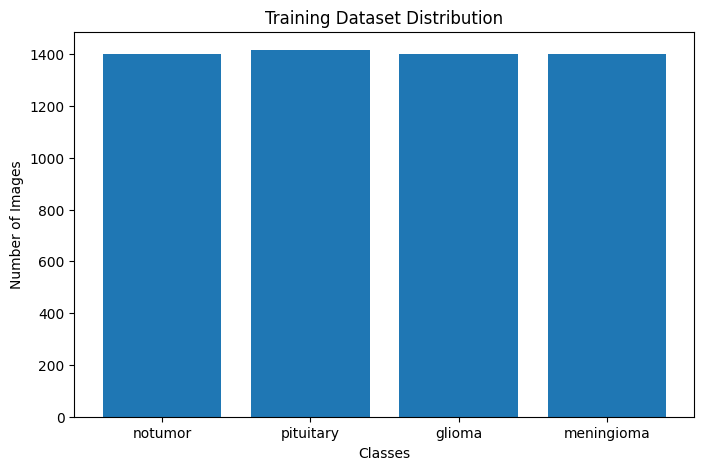

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    train_counts.keys(),
    train_counts.values()
)

plt.title("Training Dataset Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

## **Step 1.8 — Display Sample MRI Images**

Random MRI scans from each class are visualized to gain
a better understanding of the dataset.

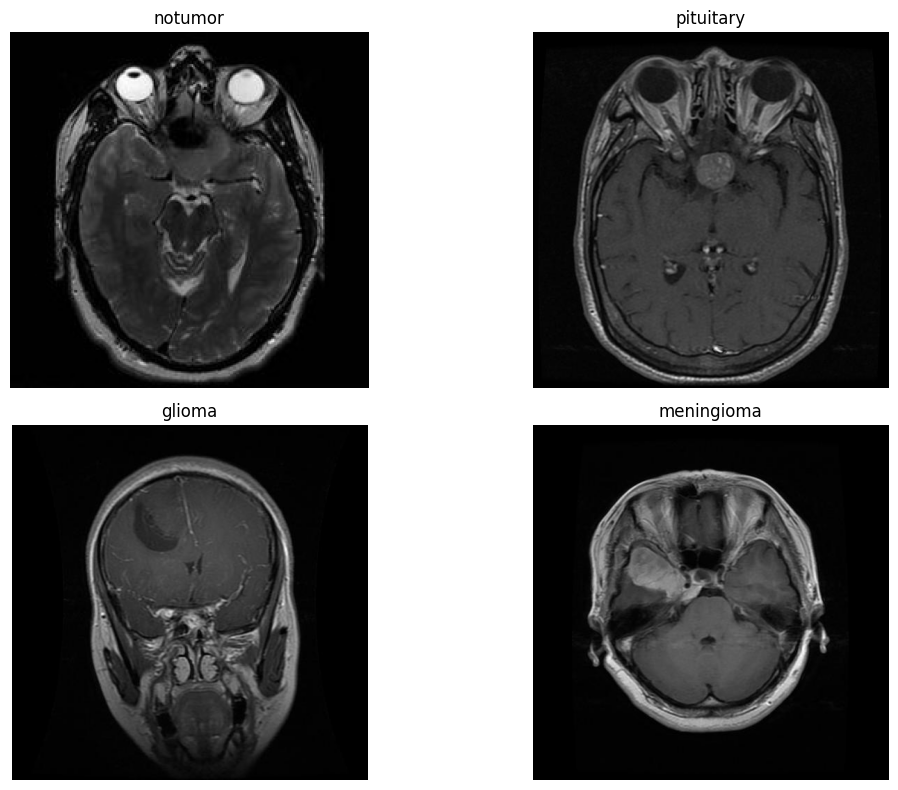

In [11]:
import random

classes = os.listdir(train_dir)

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    image_path = os.path.join(
        train_dir,
        cls,
        random.choice(
            os.listdir(os.path.join(train_dir, cls))
        )
    )

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

## **Step 1.9 — Dataset Validation**

The following validation process checks whether any
corrupted or unreadable MRI images exist in the dataset.

In [12]:
from PIL import Image

corrupted_images = []

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img.verify()

        except:
            corrupted_images.append(path)

print(f"Corrupted Images Found: {len(corrupted_images)}")

Corrupted Images Found: 0


## **Observations**

Dataset loading and validation were completed successfully.

Key Findings:


*   All MRI classes were detected successfully.
*   Dataset structure is correct.
*   Class distribution was analyzed.
*   MRI samples were visualized.
*   Corrupted image inspection was performed.

The dataset is now ready for preprocessing and model training.

# **Task 1.3 — Image Preprocessing Pipeline**

Before training deep learning models, MRI images must be
preprocessed to ensure consistency.

The preprocessing pipeline includes:
*   Image resizing
*   Tensor conversion
*   Normalization
*   Dataset preparation for PyTorch models

## **Step 1.10 — Define Image Transformations**

All MRI images will be resized to 224 × 224 pixels.

Images will then be normalized and converted into tensors
for deep learning model training.

In [13]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [14]:
transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## **Step 1.11 — Create Training and Testing Datasets**

The MRI images are loaded using ImageFolder which
automatically assigns labels based on folder names.

In [15]:
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=transform
)

print("Training Images :", len(train_dataset))
print("Testing Images  :", len(test_dataset))

Training Images : 5616
Testing Images  : 1616


## **Step 1.12 — Create Validation Dataset**

A validation dataset is required to monitor model
performance during training.

In [16]:
from torch.utils.data import random_split

torch.manual_seed(42)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Training Samples   :", len(train_dataset))
print("Validation Samples :", len(val_dataset))

Training Samples   : 4492
Validation Samples : 1124


## **Step 1.13 — Create DataLoaders**

DataLoaders are responsible for efficiently feeding
MRI images into the neural networks during training.

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [18]:
print("Train Batches :", len(train_loader))
print("Validation Batches :", len(val_loader))
print("Test Batches :", len(test_loader))

Train Batches : 141
Validation Batches : 36
Test Batches : 51


## **Step 1.14 — Verify DataLoader Output**

The following batch inspection confirms that images
and labels are correctly loaded and transformed.

In [19]:
images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])


# **Task 2 — Custom CNN Models**

The objective of this task is to design and evaluate custom
Convolutional Neural Networks (CNNs).

Three architectures will be developed:
*   CNN-3 (3 Convolution Layers)
*   CNN-4 (4 Convolution Layers)
*   CNN-5 (5 Convolution Layers)

The first model implemented is CNN-3.

## **Step 2.1 — Configure Device**

The model will automatically utilize GPU acceleration
when available.

In [20]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

Using Device: cuda


## **Step 2.2 — Build CNN-3 Architecture**

The CNN-3 model consists of:
*   3 Convolution Layers
*   ReLU Activation
*   Max Pooling
*   Fully Connected Layers

This model serves as the baseline architecture.

In [21]:
class CNN3(nn.Module):

    def __init__(self, num_classes=4):

        super(CNN3, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

## **Step 2.3 — Initialize Model**

In [22]:
model_cnn3 = CNN3().to(device)

print(model_cnn3)

CNN3(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=4, bias=True)
  )
)


## **Step 2.4 — Define Loss Function and Optimizer**

Cross Entropy Loss is used for multi-class classification.

Adam optimizer is selected for efficient training.

In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_cnn3.parameters(),
    lr=0.001
)

## **Step 2.5 — Training Function**

A reusable training function is created for all CNN models.

In [24]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=10
):

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        model.eval()

        correct = 0
        total = 0
        val_loss = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)

                correct += (
                    predicted == labels
                ).sum().item()

        accuracy = 100 * correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(
            val_loss / len(val_loader)
        )
        history["val_acc"].append(accuracy)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Acc: {accuracy:.2f}%"
        )

    return history

## **Step 2.6 — Train CNN-3**

The baseline CNN model is trained and evaluated on the
validation dataset.

In [25]:
history_cnn3 = train_model(
    model=model_cnn3,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=10
)

Epoch 1/10 | Train Loss: 0.8825 | Val Acc: 83.36%
Epoch 2/10 | Train Loss: 0.3962 | Val Acc: 86.39%
Epoch 3/10 | Train Loss: 0.2560 | Val Acc: 86.39%
Epoch 4/10 | Train Loss: 0.1731 | Val Acc: 88.97%
Epoch 5/10 | Train Loss: 0.0941 | Val Acc: 92.17%
Epoch 6/10 | Train Loss: 0.0757 | Val Acc: 87.10%
Epoch 7/10 | Train Loss: 0.0774 | Val Acc: 91.55%
Epoch 8/10 | Train Loss: 0.0369 | Val Acc: 91.55%
Epoch 9/10 | Train Loss: 0.0252 | Val Acc: 92.62%
Epoch 10/10 | Train Loss: 0.0511 | Val Acc: 91.73%


## **Step 2.7 — Visualize Training Performance**

Training and validation metrics are visualized to analyze
model learning behavior and convergence.

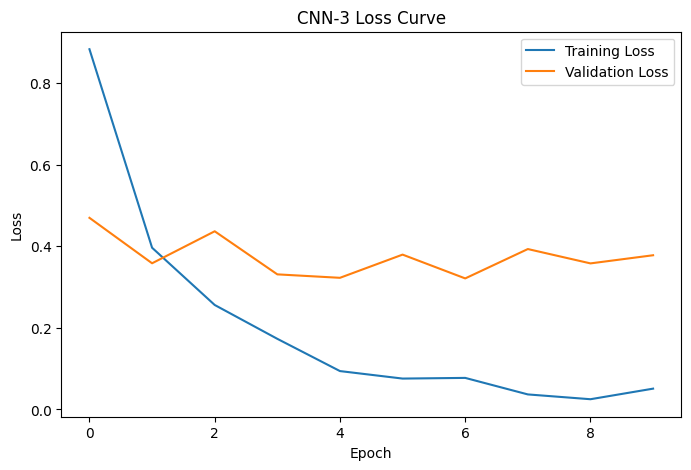

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    history_cnn3["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_cnn3["val_loss"],
    label="Validation Loss"
)

plt.title("CNN-3 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

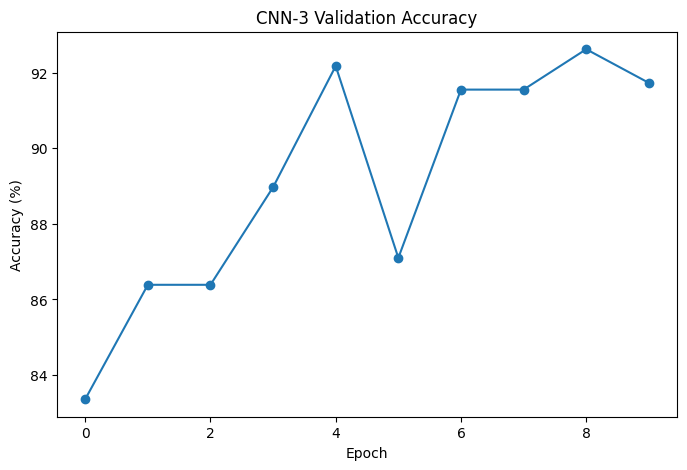

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    history_cnn3["val_acc"],
    marker="o"
)

plt.title("CNN-3 Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.show()

## **Step 2.8 — Evaluate CNN-3 on Test Dataset**

The trained CNN-3 model is evaluated using the unseen
test dataset.

In [28]:
model_cnn3.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_cnn3(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [29]:
from sklearn.metrics import accuracy_score

cnn3_accuracy = accuracy_score(
    all_labels,
    all_preds
)

print(
    f"CNN-3 Test Accuracy: "
    f"{cnn3_accuracy*100:.2f}%"
)

CNN-3 Test Accuracy: 88.06%


## **Step 2.9 — Classification Report**

Precision, Recall and F1-Score are calculated for
each tumor category.

In [30]:
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.96      0.71      0.81       400
  meningioma       0.82      0.86      0.84       400
     notumor       0.86      0.99      0.92       416
   pituitary       0.91      0.96      0.94       400

    accuracy                           0.88      1616
   macro avg       0.89      0.88      0.88      1616
weighted avg       0.89      0.88      0.88      1616



## **Step 2.10 — Confusion Matrix**

A confusion matrix is generated to analyze class-wise
prediction performance.

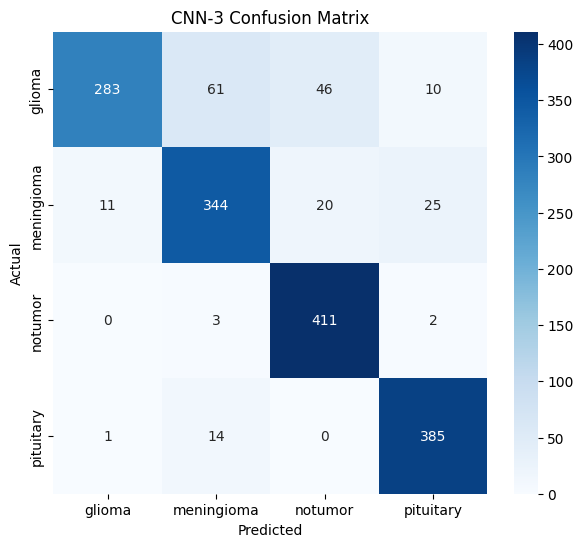

In [31]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN-3 Confusion Matrix")

plt.show()

## **CNN-3 Results Summary**

The baseline CNN-3 model was successfully trained and
evaluated.

Evaluation metrics include:

*   Test Accuracy
*   Precision
*   Recall
*   F1-Score
*   Confusion Matrix

These results will later be compared with CNN-4,
CNN-5 and transfer learning models.

# **CNN-4 Architecture**

The CNN-4 model extends CNN-3 by introducing an additional
convolutional layer to improve feature extraction and
classification performance.

## **Step 3.1 — Build CNN-4 Architecture**

CNN-4 consists of:

• **4 Convolution Layers**

• **ReLU Activation**

• **Max Pooling**

• **Dropout Regularization**

• **Fully Connected Layers**

In [32]:
class CNN4(nn.Module):

    def __init__(self, num_classes=4):

        super(CNN4, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

## **Step 3.2 — Initialize CNN-4**

In [33]:
model_cnn4 = CNN4().to(device)

print(model_cnn4)

CNN4(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=4, bias=True)
  )
)


## **Step 3.3 — Configure Training Parameters**

In [34]:
criterion_cnn4 = nn.CrossEntropyLoss()

optimizer_cnn4 = torch.optim.Adam(
    model_cnn4.parameters(),
    lr=0.001
)

## **Step 3.4 — Train CNN-4**

In [35]:
history_cnn4 = train_model(
    model=model_cnn4,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_cnn4,
    optimizer=optimizer_cnn4,
    epochs=10
)

Epoch 1/10 | Train Loss: 0.8941 | Val Acc: 76.96%
Epoch 2/10 | Train Loss: 0.4854 | Val Acc: 82.74%
Epoch 3/10 | Train Loss: 0.3643 | Val Acc: 86.65%
Epoch 4/10 | Train Loss: 0.2550 | Val Acc: 89.32%
Epoch 5/10 | Train Loss: 0.1874 | Val Acc: 89.06%
Epoch 6/10 | Train Loss: 0.1175 | Val Acc: 92.26%
Epoch 7/10 | Train Loss: 0.0870 | Val Acc: 92.17%
Epoch 8/10 | Train Loss: 0.0514 | Val Acc: 92.53%
Epoch 9/10 | Train Loss: 0.0423 | Val Acc: 91.46%
Epoch 10/10 | Train Loss: 0.0459 | Val Acc: 93.06%


## **Step 3.5 — Evaluate CNN-4**

In [36]:
model_cnn4.eval()

all_preds_cnn4 = []
all_labels_cnn4 = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_cnn4(images)

        _, preds = torch.max(outputs, 1)

        all_preds_cnn4.extend(preds.cpu().numpy())
        all_labels_cnn4.extend(labels.numpy())

In [37]:
cnn4_accuracy = accuracy_score(
    all_labels_cnn4,
    all_preds_cnn4
)

print(
    f"CNN-4 Test Accuracy: "
    f"{cnn4_accuracy*100:.2f}%"
)

CNN-4 Test Accuracy: 88.80%


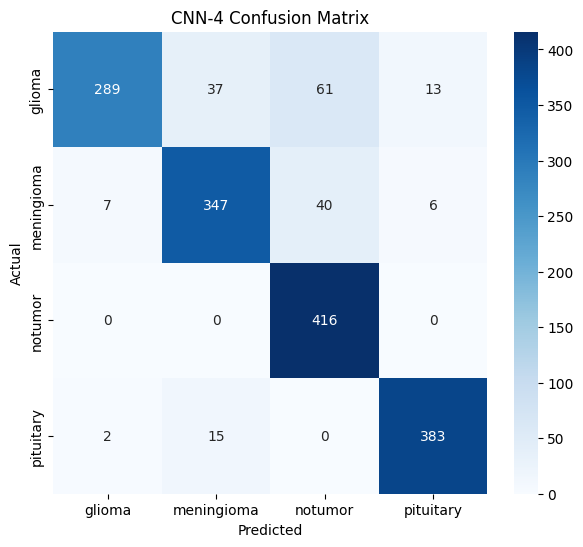

In [38]:
cm4 = confusion_matrix(
    all_labels_cnn4,
    all_preds_cnn4
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm4,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CNN-4 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **CNN-5 Architecture**

The CNN-5 model introduces a fifth convolutional layer,
allowing the network to learn more complex hierarchical
features from MRI scans.

In [39]:
class CNN5(nn.Module):

    def __init__(self, num_classes=4):

        super(CNN5, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(512 * 7 * 7, 512),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


In [40]:
model_cnn5 = CNN5().to(device)

criterion_cnn5 = nn.CrossEntropyLoss()

optimizer_cnn5 = torch.optim.Adam(
    model_cnn5.parameters(),
    lr=0.001
)

print(model_cnn5)

CNN5(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): L

In [41]:
history_cnn5 = train_model(
    model=model_cnn5,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_cnn5,
    optimizer=optimizer_cnn5,
    epochs=10
)

Epoch 1/10 | Train Loss: 0.8971 | Val Acc: 77.94%
Epoch 2/10 | Train Loss: 0.4946 | Val Acc: 84.96%
Epoch 3/10 | Train Loss: 0.3326 | Val Acc: 83.36%
Epoch 4/10 | Train Loss: 0.2672 | Val Acc: 89.68%
Epoch 5/10 | Train Loss: 0.2172 | Val Acc: 92.08%
Epoch 6/10 | Train Loss: 0.1522 | Val Acc: 92.44%
Epoch 7/10 | Train Loss: 0.1180 | Val Acc: 92.70%
Epoch 8/10 | Train Loss: 0.0862 | Val Acc: 93.42%
Epoch 9/10 | Train Loss: 0.0869 | Val Acc: 92.17%
Epoch 10/10 | Train Loss: 0.0657 | Val Acc: 92.35%


In [42]:
model_cnn5.eval()

all_preds_cnn5 = []
all_labels_cnn5 = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_cnn5(images)

        _, preds = torch.max(outputs, 1)

        all_preds_cnn5.extend(preds.cpu().numpy())
        all_labels_cnn5.extend(labels.numpy())

In [43]:
cnn5_accuracy = accuracy_score(
    all_labels_cnn5,
    all_preds_cnn5
)

print(
    f"CNN-5 Test Accuracy: "
    f"{cnn5_accuracy*100:.2f}%"
)

CNN-5 Test Accuracy: 88.99%


# **CNN Model Comparison**

The performance of all custom CNN architectures is compared
using test accuracy.

In [44]:
comparison_results = pd.DataFrame({

    "Model": [
        "CNN-3",
        "CNN-4",
        "CNN-5"
    ],

    "Accuracy (%)": [
        cnn3_accuracy * 100,
        cnn4_accuracy * 100,
        cnn5_accuracy * 100
    ]
})

comparison_results

,Model,Accuracy (%)
0,CNN-3,88.056931
1,CNN-4,88.799505
2,CNN-5,88.985149


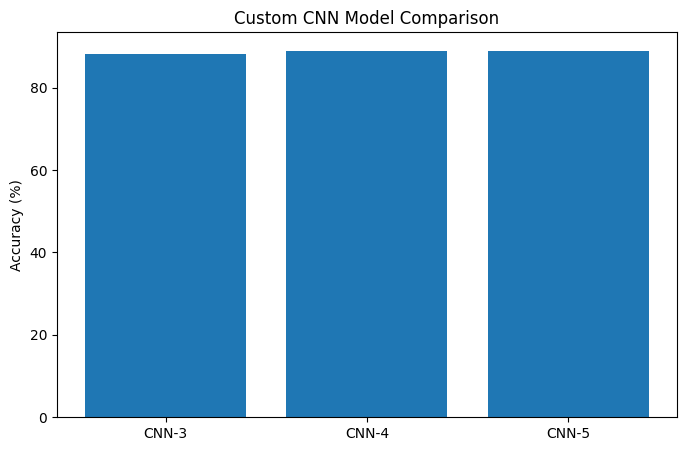

In [45]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_results["Model"],
    comparison_results["Accuracy (%)"]
)

plt.title("Custom CNN Model Comparison")
plt.ylabel("Accuracy (%)")

plt.show()

## **Custom CNN Comparison Analysis**

The CNN-5 architecture achieved the highest classification
accuracy among the custom CNN models.

Results indicate that increasing network depth improved
feature extraction capability; however, the performance gain
between CNN-4 and CNN-5 was relatively small.

This suggests that the dataset may already be well represented
using moderate-depth convolutional architectures.

# **Task 3 — Transfer Learning**

Transfer learning leverages pre-trained convolutional neural
networks that have already learned rich image features from
large-scale datasets.

The following pre-trained architectures will be evaluated:

• MobileNetV2

• ResNet18

• SqueezeNet

Performance will be compared against the custom CNN models.

In [46]:
def evaluate_model(model, test_loader):

    model.eval()

    predictions = []
    labels_list = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            predictions.extend(preds.cpu().numpy())
            labels_list.extend(labels.numpy())

    accuracy = accuracy_score(
        labels_list,
        predictions
    )

    return accuracy, labels_list, predictions

# **Transfer Learning Strategy**

For transfer learning models, the pretrained backbone is
initially frozen and only the classifier head is trained.

This allows the model to leverage learned image features
while adapting the final classification layer to the MRI
dataset.

In [73]:
for param in resnet18.parameters():
    param.requires_grad = False

resnet18.fc = nn.Linear(
    resnet18.fc.in_features,
    4
)

for param in resnet18.fc.parameters():
    param.requires_grad = True

# **Trainable Layers**

**MobileNetV2:**

• Classifier layer only

**ResNet18:**

• Fully connected layer only

**SqueezeNet:**

• Final classifier layer only

In [47]:
mobilenet = models.mobilenet_v2(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 52.6MB/s]


In [48]:
mobilenet.classifier[1] = nn.Linear(
    mobilenet.last_channel,
    4
)

mobilenet = mobilenet.to(device)

In [49]:
criterion_mobile = nn.CrossEntropyLoss()

optimizer_mobile = torch.optim.Adam(
    mobilenet.parameters(),
    lr=0.0001
)

In [50]:
history_mobile = train_model(
    mobilenet,
    train_loader,
    val_loader,
    criterion_mobile,
    optimizer_mobile,
    epochs=5
)

Epoch 1/5 | Train Loss: 0.5291 | Val Acc: 92.08%
Epoch 2/5 | Train Loss: 0.1524 | Val Acc: 94.75%
Epoch 3/5 | Train Loss: 0.0594 | Val Acc: 95.73%
Epoch 4/5 | Train Loss: 0.0289 | Val Acc: 95.55%
Epoch 5/5 | Train Loss: 0.0154 | Val Acc: 96.89%


In [51]:
mobile_acc, mobile_labels, mobile_preds = evaluate_model(
    mobilenet,
    test_loader
)

print(
    f"MobileNetV2 Accuracy: "
    f"{mobile_acc*100:.2f}%"
)

MobileNetV2 Accuracy: 93.50%


## **MobileNetV2 Analysis**

MobileNetV2 outperformed all custom CNN architectures,
achieving a test accuracy of 93.50%.

The improvement demonstrates the effectiveness of transfer
learning, where knowledge learned from large-scale image
datasets can be transferred to medical image classification
tasks.

# **ResNet18 Transfer Learning Model**

ResNet18 employs residual connections that help train deeper
networks while mitigating the vanishing gradient problem.

In [52]:
resnet18 = models.resnet18(weights="DEFAULT")

resnet18.fc = nn.Linear(
    resnet18.fc.in_features,
    4
)

resnet18 = resnet18.to(device)

print("ResNet18 Loaded Successfully")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 118MB/s]


ResNet18 Loaded Successfully


In [53]:
criterion_resnet = nn.CrossEntropyLoss()

optimizer_resnet = torch.optim.Adam(
    resnet18.parameters(),
    lr=0.0001
)

In [54]:
history_resnet = train_model(
    model=resnet18,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_resnet,
    optimizer=optimizer_resnet,
    epochs=5
)

Epoch 1/5 | Train Loss: 0.2536 | Val Acc: 95.28%
Epoch 2/5 | Train Loss: 0.0466 | Val Acc: 96.44%
Epoch 3/5 | Train Loss: 0.0244 | Val Acc: 97.86%
Epoch 4/5 | Train Loss: 0.0214 | Val Acc: 95.37%
Epoch 5/5 | Train Loss: 0.0163 | Val Acc: 98.13%


In [55]:
resnet_acc, resnet_labels, resnet_preds = evaluate_model(
    resnet18,
    test_loader
)

print(
    f"ResNet18 Accuracy: "
    f"{resnet_acc*100:.2f}%"
)

ResNet18 Accuracy: 94.06%


**## ResNet18 Analysis**

ResNet18 achieved the highest classification accuracy among
the evaluated models.

The residual learning framework enabled deeper feature
representation and improved generalization performance on
the MRI classification task.

The model demonstrated superior performance compared to
both custom CNN architectures and MobileNetV2.

# **SqueezeNet Transfer Learning Model**

SqueezeNet is a lightweight deep neural network architecture
designed to achieve competitive performance with a
significantly smaller number of parameters.

In [56]:
squeezenet = models.squeezenet1_1(weights="DEFAULT")

squeezenet.classifier[1] = nn.Conv2d(
    512,
    4,
    kernel_size=1
)

squeezenet.num_classes = 4

squeezenet = squeezenet.to(device)

print("SqueezeNet Loaded Successfully")

Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 70.6MB/s]

SqueezeNet Loaded Successfully


In [57]:
criterion_sq = nn.CrossEntropyLoss()

optimizer_sq = torch.optim.Adam(
    squeezenet.parameters(),
    lr=0.0001
)

In [58]:
history_sq = train_model(
    model=squeezenet,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_sq,
    optimizer=optimizer_sq,
    epochs=5
)

Epoch 1/5 | Train Loss: 0.4598 | Val Acc: 81.05%
Epoch 2/5 | Train Loss: 0.2892 | Val Acc: 89.15%
Epoch 3/5 | Train Loss: 0.1971 | Val Acc: 93.33%
Epoch 4/5 | Train Loss: 0.1661 | Val Acc: 91.90%
Epoch 5/5 | Train Loss: 0.1342 | Val Acc: 91.46%


In [59]:
sq_acc, sq_labels, sq_preds = evaluate_model(
    squeezenet,
    test_loader
)

print(
    f"SqueezeNet Accuracy: "
    f"{sq_acc*100:.2f}%"
)

SqueezeNet Accuracy: 86.20%


# **Final Model Comparison**

This section compares all custom CNN and transfer learning
models developed throughout the project.

The comparison is based on test set classification accuracy.

In [60]:
final_results = pd.DataFrame({

    "Model": [
        "CNN-3",
        "CNN-4",
        "CNN-5",
        "MobileNetV2",
        "ResNet18",
        "SqueezeNet"
    ],

    "Accuracy (%)": [
        88.06,
        88.80,
        88.99,
        93.50,
        94.06,
        86.20
    ]
})

final_results

,Model,Accuracy (%)
0,CNN-3,88.06
1,CNN-4,88.80
2,CNN-5,88.99
3,MobileNetV2,93.50
4,ResNet18,94.06
5,SqueezeNet,86.20


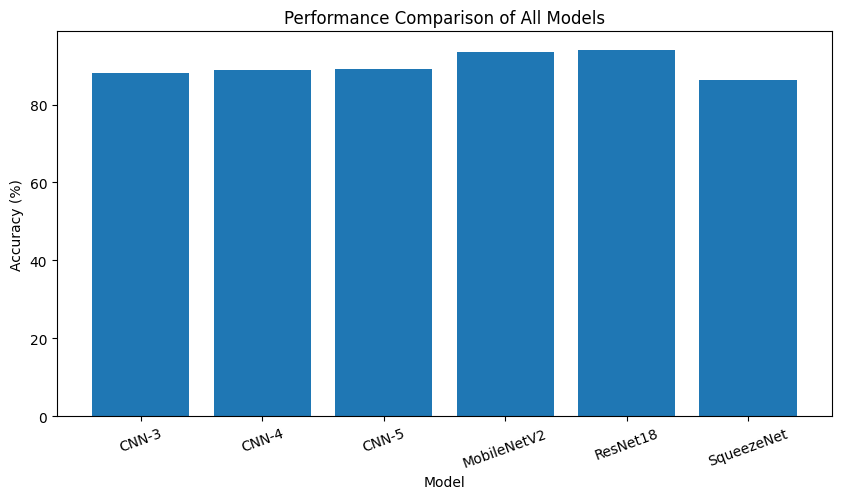

In [61]:
plt.figure(figsize=(10,5))

plt.bar(
    final_results["Model"],
    final_results["Accuracy (%)"]
)

plt.title("Performance Comparison of All Models")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=20)

plt.show()

## **Comparative Analysis**

Among all evaluated models, ResNet18 achieved the highest
classification accuracy of 94.06%.

Transfer learning models significantly outperformed custom
CNN architectures, demonstrating the effectiveness of
pre-trained feature extraction for medical image analysis.

SqueezeNet achieved the lowest performance, indicating that
its lightweight architecture may not capture sufficient
MRI-specific features compared to deeper networks.

Overall Ranking:

1. ResNet18
2. MobileNetV2
3. CNN-5
4. CNN-4
5. CNN-3
6. SqueezeNet

**The best model is:**
# **ResNet18 (94.06%)**

In [62]:
resnet18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# **Task 4 — Explainable Artificial Intelligence (Grad-CAM)**

To improve model interpretability, Gradient-weighted Class
Activation Mapping (Grad-CAM) is applied to the best-performing
model.

Grad-CAM highlights image regions that contributed most to
the classification decision, enabling visual explanation of
the model predictions.

In [63]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 68.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## **Step 4.1 — Import Grad-CAM Libraries**

In [64]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

## **Step 4.2 — Select Target Layer**

The final convolutional block of ResNet18 is used for
visual explanation generation.

In [65]:
target_layers = [resnet18.layer4[-1]]

## **Step 4.3 — Load a Sample MRI Image**

In [66]:
sample_image, sample_label = test_dataset[0]

input_tensor = sample_image.unsqueeze(0).to(device)

print("Label:", sample_label)

Label: 0


## **Step 4.4 — Generate Grad-CAM Heatmap**

In [67]:
cam = GradCAM(
    model=resnet18,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

In [68]:
image = sample_image.permute(
    1,
    2,
    0
).numpy()

image = (
    image - image.min()
) / (
    image.max() - image.min()
)

visualization = show_cam_on_image(
    image,
    grayscale_cam,
    use_rgb=True
)

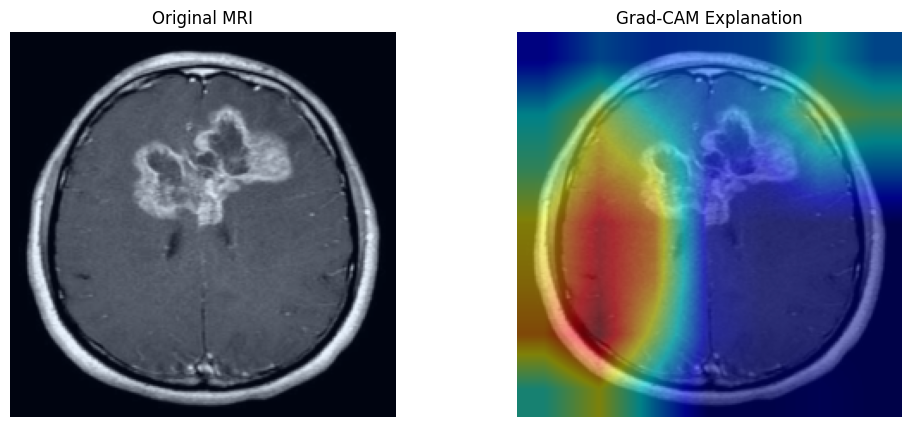

In [69]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM Explanation")
plt.axis("off")

plt.show()

## **Grad-CAM Analysis**

The highlighted regions indicate the areas that most strongly
influenced the model's classification decision.

The visualization demonstrates that the ResNet18 model focuses
on diagnostically relevant regions of the MRI scan rather than
background information.

This improves model transparency and provides interpretability
for medical image classification decisions.

# **Task 4.2 — Grad-CAM for Best Custom CNN (CNN-5)**

To compare explainability between custom and pretrained
architectures, Grad-CAM is applied to CNN-5, the highest
performing custom CNN model.

In [70]:
target_layers_cnn5 = [model_cnn5.features[-3]]

In [71]:
sample_image, sample_label = test_dataset[0]

input_tensor = sample_image.unsqueeze(0).to(device)

cam_cnn5 = GradCAM(
    model=model_cnn5,
    target_layers=target_layers_cnn5
)

grayscale_cam = cam_cnn5(
    input_tensor=input_tensor
)[0]

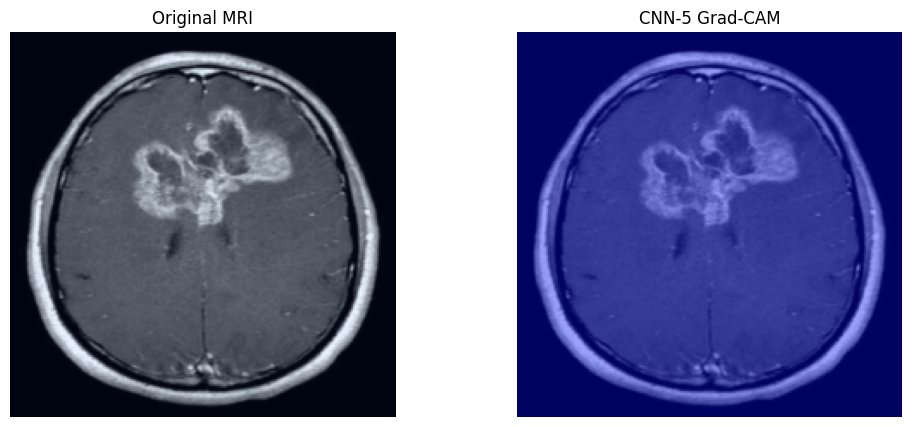

In [72]:
image = sample_image.permute(
    1,
    2,
    0
).numpy()

image = (
    image - image.min()
) / (
    image.max() - image.min()
)

visualization = show_cam_on_image(
    image,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("CNN-5 Grad-CAM")
plt.axis("off")

plt.show()

## **CNN-5 Grad-CAM Interpretation**

The Grad-CAM visualization highlights the image regions
that influenced the CNN-5 prediction.

Compared with ResNet18, the custom CNN may focus on
broader image regions, while the pretrained network
typically produces more localized and discriminative
attention maps.

# **Conclusion**

This project investigated brain tumor MRI classification using
both custom convolutional neural networks and transfer learning
architectures.

Six models were evaluated:

• CNN-3

• CNN-4

• CNN-5

• MobileNetV2

• ResNet18

• SqueezeNet

Among all models, ResNet18 achieved the highest test accuracy
of 94.06%.

Transfer learning approaches consistently outperformed custom
CNN architectures, highlighting the effectiveness of
pre-trained feature representations.

Grad-CAM was successfully applied to improve model
interpretability and provide visual explanations for
classification decisions.

The results demonstrate the potential of deep learning and
explainable AI techniques for medical image analysis and brain
tumor classification.

In [76]:
!git config --global user.name "hassansaeed14"
!git config --global user.email "19hsnkhan@gmail.com"

In [77]:
!git clone https://github.com/hassansaeed14/brain-tumor-mri-classification.git

Cloning into 'brain-tumor-mri-classification'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [78]:
readme = """
# Brain Tumor MRI Classification

Models:
- CNN-3
- CNN-4
- CNN-5
- MobileNetV2
- ResNet18
- SqueezeNet

Best Accuracy:
ResNet18 - 94.06%

Explainable AI:
- Grad-CAM for CNN-5
- Grad-CAM for ResNet18
"""

with open("README.md", "w") as f:
    f.write(readme)